# Examining the topology of the W space

1. Do the principal component analysis (PCA) and see how much variance is captured by first K principal components. And which dims those principal components belong to.
2. Cluster ws and try to extract the concept of colour. 

In [1]:
import os
import yaml
import torch
import numpy as np
from typing import Dict, List, Tuple


TRAIN_SESSION = "sf_tabular_20260222_103653"
ONE_HOT_ACTIONS = True

# Set to True only for checkpoints where W was trained on [state, action] features.
CONCAT_ACTIONS_TO_STATE_FOR_W = False

# One of: "none", "mask_0", "mask_1", "auto"
#   - mask_0: [at_terminal, at_goal_obj]
#   - mask_1: [at_terminal, at_goal_obj, bias_term, one_hot_colour_gated, one_hot_shape_gated]
#   - auto: infer by matching checkpoint ftr_dim
SEMANTIC_FEATURE_MASK_MODE_FOR_W = "auto"

parent_dir = os.path.dirname(os.getcwd())
store_dir = os.path.join(parent_dir, "artefacts")

ckpt_pth = os.path.join(parent_dir, "algos", "artefacts", TRAIN_SESSION, "last_model.pth")
ckpt = torch.load(ckpt_pth, map_location="cpu")

hparam_pth = os.path.join(parent_dir, "algos", "artefacts", TRAIN_SESSION, "sf_tabular.yaml")
with open(hparam_pth, 'r') as f:
    hparams = yaml.safe_load(f)


/tmp/ipykernel_3067480/4059195169.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_pth, map_location="cpu")


In [2]:
# If the file already stores a raw state_dict (your sf_tabular case),
# this keeps it as-is. Otherwise, pull common wrapped keys.
if isinstance(ckpt, dict):
    if "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt
else:
    raise TypeError(f"Unsupported checkpoint type: {type(ckpt)}")

In [3]:
from envs.shapes.multitask_shapes import ShapesAttrCombFactory
from envs.shapes.shapes import RND_FTR_RNG

action_mask = hparams["experiment"].get("action_mask", 0)
hparams = hparams["environment"] if "environment" in hparams else hparams
n_cnfd_ftrs = hparams["num_confounding_features"]

env = ShapesAttrCombFactory(
    hparams=hparams,
    store_path=store_dir
).get_env(set_id="TRAIN")
obs, _ = env.reset()
print(obs["features"].shape)

num_objs = 0
num_doors = 0
for row in hparams['grid']:
    for elem in row:
        if elem == 'O' or elem == 'K':
            num_objs += 1
        if elem == 'D':
            num_doors += 1

rows = len(hparams["grid"]) - 2
cols = len(hparams["grid"][0]) - 2

colour_values = list(hparams["features"]["colour"])
shape_values = list(hparams["features"]["shape"])
object_shape_values = [shape for shape in shape_values if shape != "door"]

raw_obj_ftrs = 5 + n_cnfd_ftrs
raw_door_ftrs = 4 + n_cnfd_ftrs
onehot_obj_ftrs = 2 + len(colour_values) + len(object_shape_values) + 1 + n_cnfd_ftrs * RND_FTR_RNG
onehot_door_ftrs = 2 + len(colour_values) + 1 + n_cnfd_ftrs * RND_FTR_RNG

raw_obs_dim = num_objs * raw_obj_ftrs + num_doors * raw_door_ftrs + 2
onehot_obs_dim = num_objs * onehot_obj_ftrs + num_doors * onehot_door_ftrs + 2
obs_dim = int(obs["features"].shape[0])

if obs_dim == onehot_obs_dim:
    one_hot_features = True
elif obs_dim == raw_obs_dim:
    one_hot_features = False
else:
    raise ValueError(
        f"Unexpected obs dim {obs_dim}. Expected {raw_obs_dim} (integer) or {onehot_obs_dim} (one-hot)."
    )

ftr_to_idx_map = {}
idx_to_ftr_map = {}
idx_to_range_map = {}
idx = 0

def add_feature(ftr_id: str, feature_range: int):
    global idx
    ftr_to_idx_map[ftr_id] = idx
    idx_to_ftr_map[idx] = ftr_id
    idx_to_range_map[idx] = feature_range
    return 1

for i in range(num_objs):
    add_feature(f"object_{i}.x", rows)
    idx += 1

    add_feature(f"object_{i}.y", cols)
    idx += 1

    if one_hot_features:
        for colour in colour_values:
            add_feature(f"object_{i}.colour.{colour}", 2)
            idx += 1
    else:
        add_feature(f"object_{i}.colour", len(colour_values))
        idx += 1

    if one_hot_features:
        for shape in object_shape_values:
            add_feature(f"object_{i}.shape.{shape}", 2)
            idx += 1
    else:
        add_feature(f"object_{i}.shape", len(object_shape_values))
        idx += 1

    add_feature(f"object_{i}.picked_up", 2)
    idx += 1

    for j in range(n_cnfd_ftrs):
        if one_hot_features:
            for rnd_val in range(RND_FTR_RNG):
                add_feature(f"object_{i}.random_ftr_{j}.{rnd_val}", 2)
                idx += 1
        else:
            add_feature(f"object_{i}.random_ftr_{j}", RND_FTR_RNG)
            idx += 1

for i in range(num_doors):
    add_feature(f"door_{i}.x", rows)
    idx += 1

    add_feature(f"door_{i}.y", cols)
    idx += 1

    if one_hot_features:
        for colour in colour_values:
            add_feature(f"door_{i}.colour.{colour}", 2)
            idx += 1
    else:
        add_feature(f"door_{i}.colour", len(colour_values))
        idx += 1

    add_feature(f"door_{i}.locked", 2)
    idx += 1

    for j in range(n_cnfd_ftrs):
        if one_hot_features:
            for rnd_val in range(RND_FTR_RNG):
                add_feature(f"door_{i}.random_ftr_{j}.{rnd_val}", 2)
                idx += 1
        else:
            add_feature(f"door_{i}.random_ftr_{j}", RND_FTR_RNG)
            idx += 1

add_feature("agent.x", rows)
idx += 1

add_feature("agent.y", cols)
idx += 1

base_state_dim = idx

actions = ["up", "down", "left", "right", "pick_up", "drop", "use"]
actions = actions if action_mask == 0 else actions[:-action_mask]
action_feature_dim = len(actions) if ONE_HOT_ACTIONS else 1

semantic_feature_specs = {
    "none": [],
    "mask_0": [
        ("semantic.at_terminal", 2),
        ("semantic.at_goal_obj", 2),
    ],
    "mask_1": [
        ("semantic.at_terminal", 2),
        ("semantic.at_goal_obj", 2),
        ("semantic.bias_term", 2),
    ]
    + [(f"semantic.one_hot_colour_gated.{colour}", 2) for colour in colour_values]
    + [(f"semantic.one_hot_shape_gated.{shape}", 2) for shape in object_shape_values],
}

if SEMANTIC_FEATURE_MASK_MODE_FOR_W not in ("none", "mask_0", "mask_1", "auto"):
    raise ValueError(
        f"SEMANTIC_FEATURE_MASK_MODE_FOR_W={SEMANTIC_FEATURE_MASK_MODE_FOR_W} is invalid. "
        "Use 'none', 'mask_0', 'mask_1', or 'auto'."
    )

if SEMANTIC_FEATURE_MASK_MODE_FOR_W == "auto":
    expected_dims = {}
    for mode, specs in semantic_feature_specs.items():
        expected_dims[mode] = base_state_dim + len(specs) + (action_feature_dim if CONCAT_ACTIONS_TO_STATE_FOR_W else 0)

    matches = [mode for mode, dim in expected_dims.items() if dim == state_dict["ftr_dim"]]
    if len(matches) == 1:
        semantic_feature_mode = matches[0]
    elif len(matches) == 0:
        raise ValueError(
            f"Could not infer semantic mode from checkpoint ftr_dim={state_dict['ftr_dim']}. "
            f"Expected one of {expected_dims}. Set SEMANTIC_FEATURE_MASK_MODE_FOR_W explicitly."
        )
    else:
        raise ValueError(
            f"Ambiguous semantic mode inference for ftr_dim={state_dict['ftr_dim']}: matches={matches}. "
            "Set SEMANTIC_FEATURE_MASK_MODE_FOR_W explicitly."
        )
else:
    semantic_feature_mode = SEMANTIC_FEATURE_MASK_MODE_FOR_W

for semantic_ftr, semantic_range in semantic_feature_specs[semantic_feature_mode]:
    add_feature(semantic_ftr, semantic_range)
    idx += 1

# Optional: include action dimensions for older checkpoints that used [state, action] features.
if CONCAT_ACTIONS_TO_STATE_FOR_W:
    if ONE_HOT_ACTIONS:
        for action in actions:
            add_feature(f"action.{action}", 2)
            idx += 1
    else:
        add_feature("action", env.action_space.n)
        idx += 1

if idx != state_dict["ftr_dim"]:
    raise ValueError(
        f"Feature-id map length ({idx}) does not match checkpoint ftr_dim ({state_dict['ftr_dim']}). "
        f"Settings: semantic_feature_mode={semantic_feature_mode}, "
        f"CONCAT_ACTIONS_TO_STATE_FOR_W={CONCAT_ACTIONS_TO_STATE_FOR_W}."
    )

print(
    "Feature map settings:",
    {
        "base_state_dim": base_state_dim,
        "semantic_feature_mode": semantic_feature_mode,
        "semantic_feature_count": len(semantic_feature_specs[semantic_feature_mode]),
        "concat_action_features": CONCAT_ACTIONS_TO_STATE_FOR_W,
        "final_ftr_dim": idx,
    },
)

idx_to_range_map


(17,)
Feature map settings: {'base_state_dim': 17, 'semantic_feature_mode': 'mask_0', 'semantic_feature_count': 2, 'concat_action_features': False, 'final_ftr_dim': 19}


/home/djordje/miniconda3/envs/rlexp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{0: 3,
 1: 3,
 2: 2,
 3: 2,
 4: 2,
 5: 2,
 6: 2,
 7: 2,
 8: 2,
 9: 2,
 10: 2,
 11: 2,
 12: 2,
 13: 2,
 14: 2,
 15: 3,
 16: 3,
 17: 2,
 18: 2}

In [4]:
instr_str_to_idx_map = state_dict.get("instr_map", {})
if not instr_str_to_idx_map:
    raise ValueError("No instructions found in checkpoint state_dict['instr_map'].")

instr_idx_to_str_map = {v: k for k, v in instr_str_to_idx_map.items()}
r_hat = state_dict["r_hat"]

W = []
ordered_instr_idxs = sorted(instr_idx_to_str_map.keys())
for instr_idx in ordered_instr_idxs:
    instr = instr_idx_to_str_map[instr_idx]

    if isinstance(r_hat, list):
        blob = r_hat[instr_idx]
    elif isinstance(r_hat, dict):
        blob = r_hat.get(instr)
        if blob is None:
            blob = r_hat.get(instr_idx, r_hat.get(str(instr_idx)))
    else:
        raise TypeError(f"Unsupported r_hat type: {type(r_hat)}")

    if blob is None:
        raise ValueError(f"Missing r_hat entry for instruction '{instr}' (idx={instr_idx}).")

    w = blob["state_dict"]["linear.weight"].squeeze(0)
    W.append(w.detach().cpu().numpy())

W = np.asarray(W)
if W.shape[1] != state_dict["ftr_dim"]:
    raise ValueError(f"W feature dim {W.shape[1]} does not match checkpoint ftr_dim {state_dict['ftr_dim']}.")

W.shape
instr_idx_to_str_map



{0: 'Pick up yellow square',
 1: 'Pick up green star',
 2: 'Pick up red star',
 3: 'Pick up yellow key',
 4: 'Pick up red key',
 5: 'Pick up green key',
 6: 'Pick up blue triangle',
 7: 'Pick up red ball',
 8: 'Pick up yellow star',
 9: 'Pick up blue key',
 10: 'Pick up red diamond',
 11: 'Pick up blue ball',
 12: 'Pick up yellow diamond',
 13: 'Pick up green triangle',
 14: 'Pick up blue star',
 15: 'Pick up red triangle',
 16: 'Pick up yellow triangle',
 17: 'Pick up green square',
 18: 'Pick up blue square',
 19: 'Pick up green diamond',
 20: 'Pick up blue diamond',
 21: 'Pick up yellow ball',
 22: 'Pick up green ball',
 23: 'Pick up red square'}

In [5]:
def mean_absolute_weight(W: np.ndarray) -> np.ndarray:
    return np.mean(np.abs(W), axis=0)


def _feature_type_from_ftr_id(ftr_id: str) -> str:
    if ftr_id.startswith("action"):
        return "action"

    # Semantic mask_1 gated one-hot features should be treated as categorical colour/shape groups.
    if ftr_id.startswith("semantic.one_hot_colour_gated."):
        return "semantic.colour"
    if ftr_id.startswith("semantic.one_hot_shape_gated."):
        return "semantic.shape"

    if ftr_id == "semantic.at_terminal":
        return "semantic.at_terminal"
    if ftr_id == "semantic.at_goal_obj":
        return "semantic.at_goal_obj"
    if ftr_id == "semantic.bias_term":
        return "semantic.bias_term"

    if "object_0.colour" in ftr_id:
        return "0.colour"
    if "object_1.colour" in ftr_id:
        return "1.colour"

    if "object_0.shape" in ftr_id:
        return "0.shape"
    if "object_1.shape" in ftr_id:
        return "1.shape"

    if "object_0.random_ftr_" in ftr_id:
        return "0.random_ftr"
    if "object_1.random_ftr_" in ftr_id:
        return "1.random_ftr"

    if "agent.x" in ftr_id:
        return "agent.x"
    if "agent.y" in ftr_id:
        return "agent.y"

    if "object_0.x" in ftr_id:
        return "0.x"
    if "object_0.y" in ftr_id:
        return "0.y"

    if "object_1.x" in ftr_id:
        return "1.x"
    if "object_1.y" in ftr_id:
        return "1.y"

    if "object_0.picked_up" in ftr_id:
        return "0.picked_up"
    if "object_1.picked_up" in ftr_id:
        return "1.picked_up"

    return ftr_id

import numpy as np
from typing import Dict, List, Tuple


def mean_relative_contribution_and_variance(
    W: np.ndarray,
    idx_to_ftr_map: Dict[int, str],
    idx_to_span_map: Dict[int, float],
) -> Tuple[Dict[str, float], Dict[str, float]]:
    """
    Compute per-group mean importance and variance across tasks using the
    *variance-of-contribution* metric:

        A_i(G) = sqrt( Var_x( w_{i,G}^T x_G ) )

    Assumptions (as per our discussion):
      - Numeric singleton dims j are Uniform over a span -> Var(x_j) = span_j^2 / 12
      - Categorical groups are one-hot with Uniform categories:
            w_{i,G}^T c selects one category weight
        so:
            Var( w_{i,G}^T c ) = (1/K) * sum_k (w_{i,k} - mean_k w_{i,k})^2
        and:
            A_i(G) = sqrt( Var ) = std_k(w_{i,k})

    Grouping:
      group_name = _feature_type_from_ftr_id(idx_to_ftr_map[j])

    Per-task A_i(group):
      - If group has K=1 dim j (numeric):
            A_i = |w_{i,j}| * span_j / sqrt(12)
      - If group has K>1 dims (categorical one-hot):
            A_i = std_k( w_{i, j_k} )   [= sqrt(Var over categories)]

    Outputs:
      mean_importance[group] = mean_i A_i
      var_importance[group]  = var_i  A_i
    """
    N, d = W.shape

    # Build group -> list of dims
    group_to_dims: Dict[str, List[int]] = {}
    for j in range(d):
        group = _feature_type_from_ftr_id(idx_to_ftr_map[j])
        group_to_dims.setdefault(group, []).append(j)

    mean_imp: Dict[str, float] = {}
    var_imp: Dict[str, float] = {}

    sqrt12 = np.sqrt(12.0)

    for group, dims in group_to_dims.items():
        dims_arr = np.array(dims, dtype=int)  # (K,)
        K = dims_arr.size
        Wg = W[:, dims_arr]                   # (N, K)

        if K == 1:
            # Numeric: A_i = sqrt(Var_x((w*x))) with Var(x)=span^2/12
            j = int(dims_arr[0])
            span = float(idx_to_span_map[j])
            A = np.abs(Wg[:, 0]) * (span / sqrt12)  # (N,)
        else:
            # Categorical one-hot, uniform over categories:
            # A_i = sqrt(Var over categories of selected weight) = std_k(w_{i,k})
            mu = Wg.mean(axis=1, keepdims=True)        # (N, 1)
            A = np.sqrt(((Wg - mu) ** 2).mean(axis=1)) # (N,)

        mean_imp[group] = float(A.mean())
        var_imp[group] = float(A.var())  # population variance across tasks

    return mean_imp, var_imp


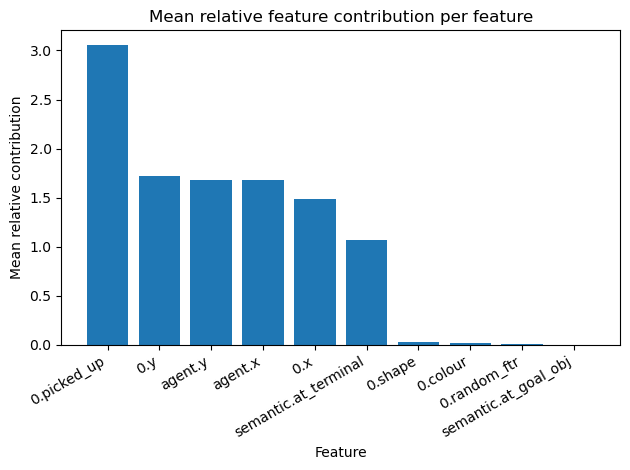

In [6]:
import matplotlib.pyplot as plt


INCLUDE_ACTION_FEATURES_IN_PLOTS = False


def plot_ftr_importance(
    x,
    idx_to_ftr_map: dict[int, str] | None = None,
    ylabel: str = "",
    title: str = "",
    rotation: int = 60,
    include_action_features: bool = True,
):
    """Plot feature importance from either:
      1) per-dimension array x (uses idx_to_ftr_map labels), or
      2) grouped dict x[label] -> value (already aggregated labels).

    Set include_action_features=False to hide action-related features.
    """
    if isinstance(x, dict):
        items = [(k, float(v)) for k, v in x.items()]
        if not include_action_features:
            items = [(k, v) for k, v in items if not str(k).startswith("action")]
        if len(items) == 0:
            raise ValueError("No features left to plot after filtering.")

        labels = np.array([k for k, _ in items], dtype=object)
        values = np.array([v for _, v in items], dtype=float)
        sort_idx = np.argsort(values)[::-1]
        labels = labels[sort_idx]
        values = values[sort_idx]
    else:
        x = np.asarray(x)
        if not include_action_features:
            if idx_to_ftr_map is None:
                raise ValueError("idx_to_ftr_map is required to filter action features for array input.")
            keep_idx = [i for i in range(x.shape[0]) if not idx_to_ftr_map[i].startswith("action")]
            if len(keep_idx) == 0:
                raise ValueError("No features left to plot after filtering.")
            x = x[keep_idx]
            labels_all = [idx_to_ftr_map[i] for i in keep_idx]
        else:
            labels_all = None if idx_to_ftr_map is None else [idx_to_ftr_map[i] for i in range(x.shape[0])]

        sort_idx = np.argsort(x)[::-1]
        values = x[sort_idx]
        if idx_to_ftr_map is None:
            labels = [str(int(i)) for i in sort_idx]
        else:
            labels = [labels_all[int(i)] for i in sort_idx]

    positions = np.arange(len(values))

    plt.figure()
    plt.bar(positions, values)
    plt.xticks(positions, labels, rotation=rotation, ha="right")
    plt.xlabel("Feature")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

mrc_grouped, var_grouped = mean_relative_contribution_and_variance(
    W=W,
    idx_to_ftr_map=idx_to_ftr_map, 
    idx_to_span_map=idx_to_range_map
)

plot_ftr_importance(
    x=mrc_grouped,
    ylabel="Mean relative contribution",
    title="Mean relative feature contribution per feature",
    rotation=30,
    include_action_features=INCLUDE_ACTION_FEATURES_IN_PLOTS,
)


### Analysis for sf_tabular_20260213_155900

1. `agent.y` is an important feature because it captures the semantic concepts of "going to a location". The episode only terminates when the correct (x,y) coordinates are hit. The agent must check the `agent.y` coordinate to know whether it is close to finishing the episode. This shouldn't be interpreted that `agent.y` is the differentiating factor between different tasks. It is equally important in all tasks, and its value can in fact be the same for multiple tasks (and indeed it is, since there are only two locations where the object can spawn, and both are sampled uniformly and switch during the same task).
   1. $if \texttt{agent.y} = \texttt{object.y}$ predict reward +1 else predict -1 makes sense
   2. Interestingly, `agent.x` coordinate is irrelevant. This is because the objects always spawn in the same location and, since both `agent.x` and `agent.y` differ for these locations, only one of them is enough to differentiate an object. **There should be a theoretical mechanism that guarantees correct concepts will be grounded.** For example, *require that there is a high enough variability across factored representations and across tasks, so that no compression is possible (e.g. what happened here, where either x or y is sufficient)*
2. `object_0.picked_up` because the task is to *go to the object* if the object is picked up, that means we have the wrong object. Likewise for `object_1.picked_up`, although it's interesting that there's so much difference in their importances.
3. `action.` features are there because we encode the action as a one-hot encoding. It is unclear for now if this is a good thing. With the one-hot encoding, we have one weight $w \in \mathbb{R}$ per action, whereas otherwise we would have a single weight factoring in all actions. Also, it is unclear why the agent is placing any weight there, as it doesn't really matter which action we take to transition when getting to the object (this isn't the task of picking the object up) #TODO: Check these things with Chat
4. `object.shape` and `object.colour` are last, but ahead of random features. This means weights recognise them as valuable, but due to not enough variability across tasks, other features become more prominent. 

Fixes:
1. Have objects spawn in random locations on the grid. That way `agent.x` and `agent.y` will have to be important equally, and `object_0.x`, `object_0.y`, `object_1.x`, and `object_1.y`. These will have to be equally important to capture the semantic concept of "going to".
2. Figure out why action is so important! - Seems to be far less important when action is an integer.
3. For `object.colour` and `object.shape` to be equally important, you need to have a scenario where both objects are the same colour. Again, high variability (you really need to figure out a better name for it).

**Agent generalises to: The desired object is the one I can't pick up.** This is actually a perfect argument for the necessity of your approach! The agent has incorrectly grounded things and with this approach we can examine that and see that it is wrong. However, just by looking at the reward function, all seems ok!

Experiments are currently ran where the agent can only select among four actions (`UP`, `DOWN`, `LEFT`, `RIGHT`) because that way the agent cannot manipulate the picked up flag. Hopefully it shows colour and shape flags to be more prominent.

**It makes sense for the action to have a huge mean absolute weight for each task. This is because we are estimating $r(s,a)$, not $r(s)$. Going (s, `up`) from a state just below the goal yields a +1 reward, while performing any other action yields -1.** But the question becomes, why does it have high variance across the tasks? Maybe just accidental.

**Variance doesn't make much sense now that we have defined manImportance through variance**

What the previous analysis doesn't tell you is which dimension of the $\mathbf{w}$ is used to differentiate between tasks. For that you can try PCA / clustering algorithms. **The analysis below does not make much sense. You need to figure out how to do PCA properly here. You'd like colour to generate 4 clusters, and shape to generate two clusters.** But that means you are choosing a dimension where you want to track variance. TODO: You need to explore and understand PCA and clustering better in orded to perform this kind of analysis.

Change the agent's initial position. (so that objects can be approached from all sides)
You are not adding biases! -> Which is ok, as you are currently not using them in linear regression. Your solution is 100% consistent with what is presented in Barreto et al 2018.

Why is action important -> It has learned that certain actions always lead to -1. Down for example. Right as well.
You need to normalise features - shape is 0 - 1, colour is 0 - 3, and dims are 0 - 2.

TODOs:

1. Plot tasks in the colour x shape plot. See how they cluster. for this you need somehow again to aggregate all colour related features and all shape related features into a single axis. PCA does this aggregation acording to SVD, where it derives principal components based on axes with the higest variance in data. In contrast, you do not wish to extract those with the highest variance, but specifically those you wish. refer to your ChatGPT prompt. 
2. Implement manually scaling by category size (4 for colour vs 2 for shape) and feature span (0 - 3 for x,y and 0 - 1 for others!)

In [7]:
def _dims_for_group(W, idx_to_ftr_map, token):
    d = W.shape[1]
    dims = []
    for j in range(d):
        g = _feature_type_from_ftr_id(idx_to_ftr_map[j])
        if token in g:
            dims.append(j)
    return dims

def _pc1_scores(W_sub):
    # W_sub: (N, K). Return scores (N,), pc1 vector (K,)
    X = W_sub - W_sub.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    pc1 = Vt[0]                 # (K,)
    scores = X @ pc1            # (N,)
    return scores, pc1

def colour_shape_task_coords(W, idx_to_ftr_map):
    colour_dims = _dims_for_group(W, idx_to_ftr_map, ".colour")
    shape_dims  = _dims_for_group(W, idx_to_ftr_map, ".shape")

    Wc = W[:, colour_dims]  # (N, Kc)
    Ws = W[:, shape_dims]   # (N, Ks)

    x, pc1_colour = _pc1_scores(Wc)  # x-axis
    y, pc1_shape  = _pc1_scores(Ws)  # y-axis

    return x, y, colour_dims, shape_dims, pc1_colour, pc1_shape

import matplotlib.pyplot as plt

# Task styles for "Pick up <colour> <shape>" instructions.
# Matplotlib markers: ball=o, square=s, star=*, diamond=D, triangle=^, key=X
COLOUR_TO_PLOT_COLOUR = {
    "red": "tab:red",
    "green": "tab:green",
    "blue": "tab:blue",
    "yellow": "gold",
}

SHAPE_TO_PLOT_MARKER = {
    "ball": "o",
    "square": "s",
    "star": "*",
    "diamond": "D",
    "triangle": "^",
    "key": "X",
}

DEFAULT_TASK_NAME_TO_STYLE = {
    f"Pick up {colour} {shape}": {"color": colour_plot, "marker": marker}
    for colour, colour_plot in COLOUR_TO_PLOT_COLOUR.items()
    for shape, marker in SHAPE_TO_PLOT_MARKER.items()
}

def plot_tasks_colour_shape(x, y, instr_idx_to_str_map, task_style_map=None, point_size=70):
    """
    If task_style_map is None:
      - plot default blue points + task-name annotations.

    If task_style_map is provided (task_name -> {"color": ..., "marker": ...}):
      - plot per-task styled markers,
      - do NOT annotate task names.
    """
    plt.figure()

    if task_style_map is None:
        plt.scatter(x, y)
        for i in range(len(x)):
            name = instr_idx_to_str_map.get(i, str(i))
            plt.annotate(name, (x[i], y[i]), fontsize=8)
    else:
        for i in range(len(x)):
            name = instr_idx_to_str_map.get(i, str(i))
            style = task_style_map.get(name, {})
            marker = style.get("marker", "o")
            color = style.get("color", "tab:blue")
            plt.scatter([x[i]], [y[i]], marker=marker, color=color, s=point_size)

    plt.xlabel("Colour PC1 score")
    plt.ylabel("Shape PC1 score")
    plt.title("Tasks projected onto colour/shape subspace PC1s")
    plt.show()


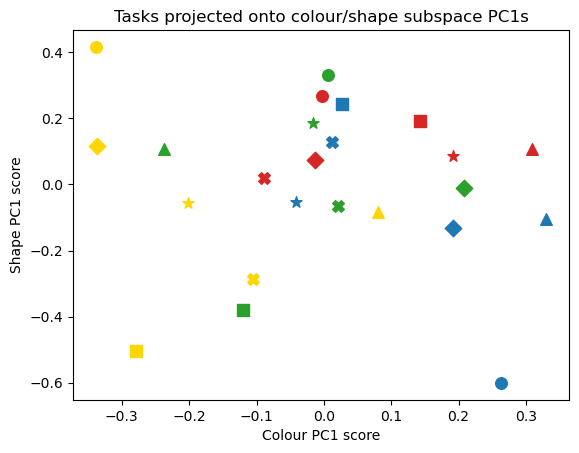

In [8]:
x, y, colour_dims, shape_dims, pc1_c, pc1_s = colour_shape_task_coords(W, idx_to_ftr_map)
plot_tasks_colour_shape(x, y, instr_idx_to_str_map, task_style_map=DEFAULT_TASK_NAME_TO_STYLE)
# plot_tasks_colour_shape(x, y, instr_idx_to_str_map, task_style_map=DEFAULT_TASK_NAME_TO_STYLE)

# TODO: See what this means. Think about this tomorrow. Clusters uncorrelated, but relative importance plots shows promise.


In [32]:
from itertools import combinations

def compute_between_task_differences(
    W: np.ndarray,
    idx_to_ftr_map: dict,
    instr_idx_to_str_map: dict,
):
    """
    Computes within-label vs between-label average distances
    in colour and shape subspaces.

    Returns:
        {
            "colour": {
                "mean_same": ...,
                "mean_diff": ...,
                "ratio": mean_same / mean_diff
            },
            "shape": {
                ...
            }
        }
    """

    N, d = W.shape

    # Use configured vocab if available; otherwise fall back to common defaults.
    colour_candidates = [str(c).lower() for c in globals().get("colour_values", ["yellow", "green", "blue", "red"])]
    shape_candidates = [str(s).lower() for s in globals().get("object_shape_values", ["ball", "key"]) if str(s).lower() != "door"]

    def _extract_label(instr: str, candidates: list[str]):
        s = instr.lower()
        for c in candidates:
            if c in s:
                return c
        return None

    # --- extract semantic labels from instruction strings ---
    colours = {}
    shapes = {}

    for idx, instr in instr_idx_to_str_map.items():
        colours[idx] = _extract_label(instr, colour_candidates)
        shapes[idx] = _extract_label(instr, shape_candidates)

    # --- extract colour and shape dimensions (object + semantic gated one-hot groups) ---
    colour_dims = []
    shape_dims = []

    for j in range(d):
        g = _feature_type_from_ftr_id(idx_to_ftr_map[j])
        if ".colour" in g:
            colour_dims.append(j)
        if ".shape" in g:
            shape_dims.append(j)

    W_colour = W[:, colour_dims]
    W_shape  = W[:, shape_dims]

    # --- helper to compute same/different averages ---
    def analyse_subspace(W_sub, labels):
        if W_sub.shape[1] == 0:
            return {
                "mean_same": float("nan"),
                "mean_diff": float("nan"),
                "ratio": float("nan"),
            }

        same_dists = []
        diff_dists = []

        for i, j in combinations(range(N), 2):
            li = labels.get(i)
            lj = labels.get(j)
            if li is None or lj is None:
                continue

            dist = np.linalg.norm(W_sub[i] - W_sub[j])

            if li == lj:
                same_dists.append(dist)
            else:
                diff_dists.append(dist)

        mean_same = float(np.mean(same_dists)) if len(same_dists) > 0 else float("nan")
        mean_diff = float(np.mean(diff_dists)) if len(diff_dists) > 0 else float("nan")

        if np.isnan(mean_same) or np.isnan(mean_diff) or mean_diff == 0.0:
            ratio = float("nan")
        else:
            ratio = float(mean_same / mean_diff)

        return {
            "mean_same": mean_same,
            "mean_diff": mean_diff,
            "ratio": ratio
        }

    results = {
        "colour": analyse_subspace(W_colour, colours),
        "shape": analyse_subspace(W_shape, shapes),
    }

    return results


In [33]:
compute_between_task_differences(
    W=W,
    idx_to_ftr_map=idx_to_ftr_map,
    instr_idx_to_str_map=instr_idx_to_str_map)

{'colour': {'mean_same': 0.1336294412612915,
  'mean_diff': 0.4134398102760315,
  'ratio': 0.32321377366169535},
 'shape': {'mean_same': 0.09700126200914383,
  'mean_diff': 0.1437939554452896,
  'ratio': 0.6745851152696793}}